In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/feature_engineered.csv")

df['Date'] = pd.to_datetime(df['Date'])

In [2]:
state_df = df[df['State'] == 'California'].copy()

In [3]:
state_df = state_df.sort_values('Date')

In [4]:
state_df = state_df[['Date', 'Sales']]

In [5]:
state_df = state_df.set_index('Date')

In [6]:
forecast_horizon = 56

In [7]:
train = state_df.iloc[:-forecast_horizon]

In [8]:
valid = state_df.iloc[-forecast_horizon:]

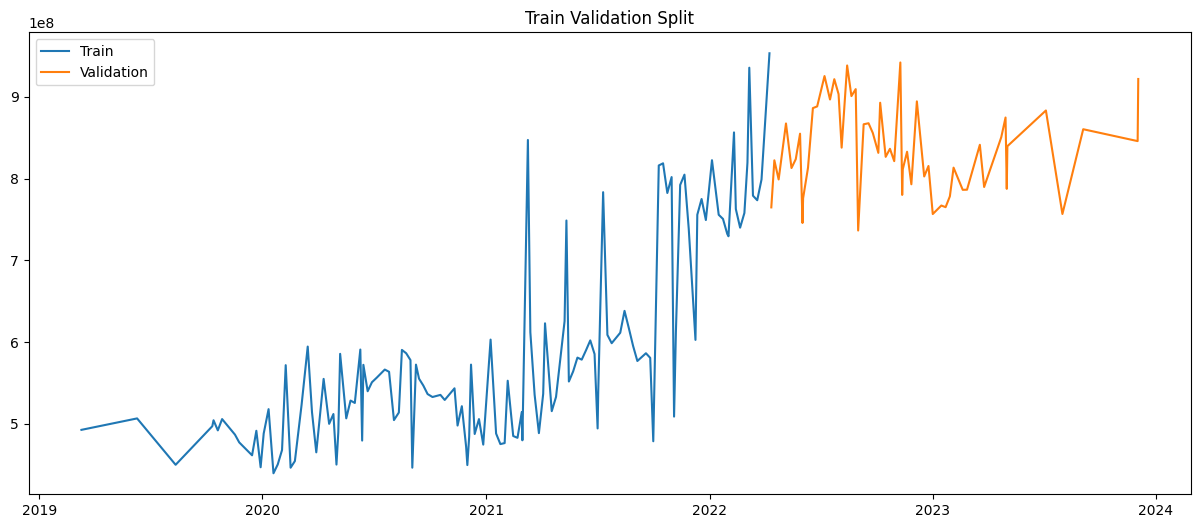

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(train.index, train['Sales'], label='Train')

plt.plot(valid.index, valid['Sales'], label='Validation')

plt.legend()

plt.title("Train Validation Split")

plt.show()

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

sarima_model = model.fit()

d:\forecasting_system\project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\forecasting_system\project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\forecasting_system\project\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [13]:
print(sarima_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                  131
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2428.356
Date:                           Thu, 07 May 2026   AIC                           4866.712
Time:                                   13:59:14   BIC                           4880.773
Sample:                                        0   HQIC                          4872.424
                                           - 131                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2740      0.287      0.956      0.339      -0.288       0.836
ma.L1         -0.7044      0.237     -2.970

In [14]:
predictions = sarima_model.forecast(steps=forecast_horizon)

d:\forecasting_system\project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\forecasting_system\project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


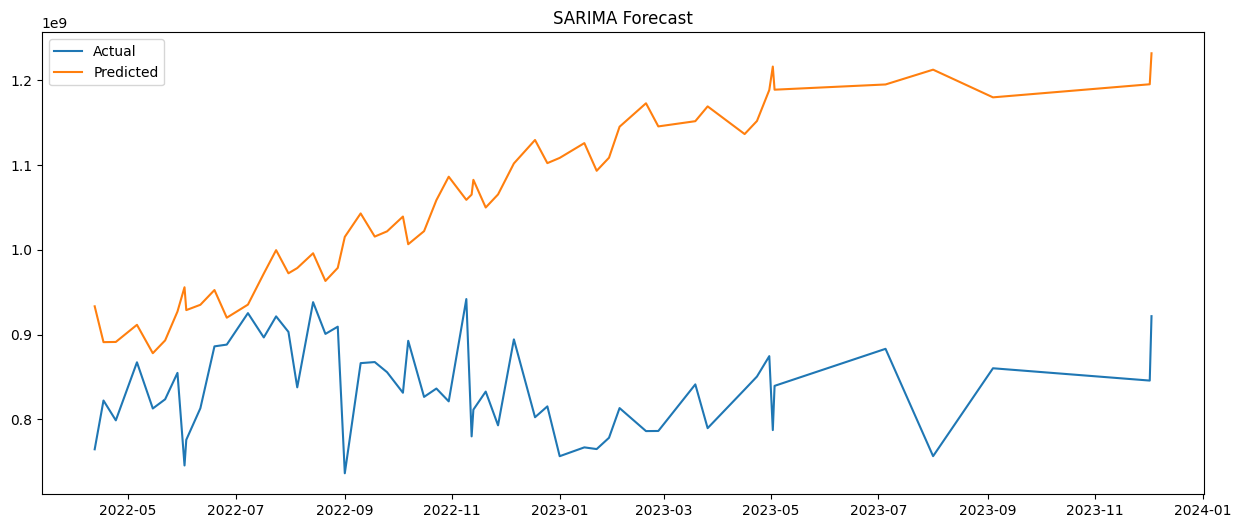

In [15]:
plt.figure(figsize=(15,6))

plt.plot(valid.index, valid['Sales'], label='Actual')

plt.plot(valid.index, predictions, label='Predicted')

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [19]:
mae = mean_absolute_error(
    valid['Sales'],
    predictions
)

print("MAE:", mae)

MAE: 215483378.0892847


In [20]:
rmse = np.sqrt(
    mean_squared_error(
        valid['Sales'],
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 246426700.29546848


In [21]:
results = {
    'Model': 'SARIMA',
    'MAE': mae,
    'RMSE': rmse
}

print(results)

{'Model': 'SARIMA', 'MAE': 215483378.0892847, 'RMSE': np.float64(246426700.29546848)}


In [22]:
import joblib

joblib.dump(
    model,
    "../models/sarima_model.pkl"
)

['../models/sarima_model.pkl']

In [23]:
results_df = pd.DataFrame([results])

results_df.to_csv(
    "../outputs/sarima_metrics.csv",
    index=False
)